In [16]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
atl = gpd.read_file("../data/atl/Census2020_Tracts_COA.geojson")
##bus_lic = pd.read_excel("../data/bus_lic/bus_lic.xlsx")
ffa = gpd.read_file("../data/ffa/Aglanta_FFA_2025_ATL_Only.shp")
lila = gpd.read_file("../data/lila/lila_halfmi_census.shp")
marta = gpd.read_file("../data/marta/MARTA_Routes_geospatial.csv")
##snap = gpd.read_file("../data/snap/snap_2025_atl.shp") 
# limited snap geospatial snap data 
txp = gpd.read_file("../data/txp/Tax_Parcels_2025.shp")
snap = gpd.read_file("../data/snap/snap_retailers.csv")


LILA (Who needs food access?)
- Areas where people both need food access and don't have it
- Serves as our demnad variable


In [17]:
lila.columns

Index(['CnssTrc', 'State', 'County', 'LILAT_1A1', 'LILAT_A', 'LILAT_1A2',
       'LILAT_V', 'PvrtyRt', 'MdnFmlI', 'LAhlf10', 'LATrct_', 'TrcSNAP',
       'tract', 'STATEFP', 'COUNTYF', 'TRACTCE', 'BLOCKCE', 'BLOCKID',
       'PARTFLG', 'HOUSING', 'POP10', 'geometry'],
      dtype='str')

[-84.850713  33.502412 -84.315716  34.056826]
[-84.58257126  33.6185594  -84.25199516  33.91588747]
EPSG:4326
EPSG:4326


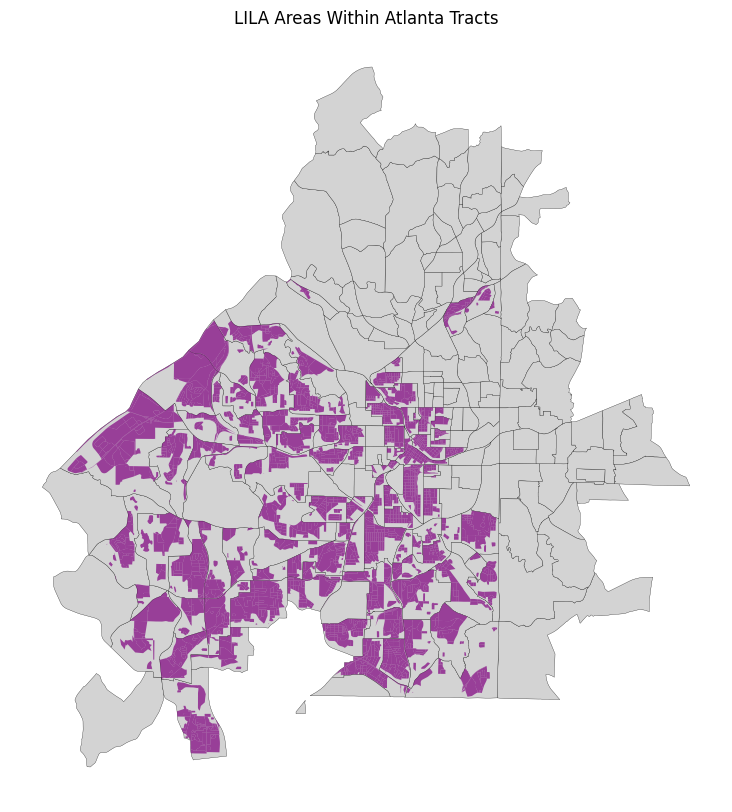

In [ ]:
print(lila.total_bounds)
print(atl.total_bounds)
lila_in_atl = gpd.sjoin(lila, atl[["GEOID", "geometry"]], how="inner", predicate="within")
print(atl.crs)
print(lila.crs)

lila = lila.set_crs("EPSG:4326", allow_override=True) 
lila = lila.to_crs(atl.crs)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

atl.plot(ax=ax, color="lightgray", edgecolor="black", linewidth=0.2)
lila_in_atl.plot(ax=ax, color="purple", markersize=12, alpha=0.7)

ax.set_title("LILA Areas Within Atlanta Tracts")
ax.set_axis_off()
plt.show()


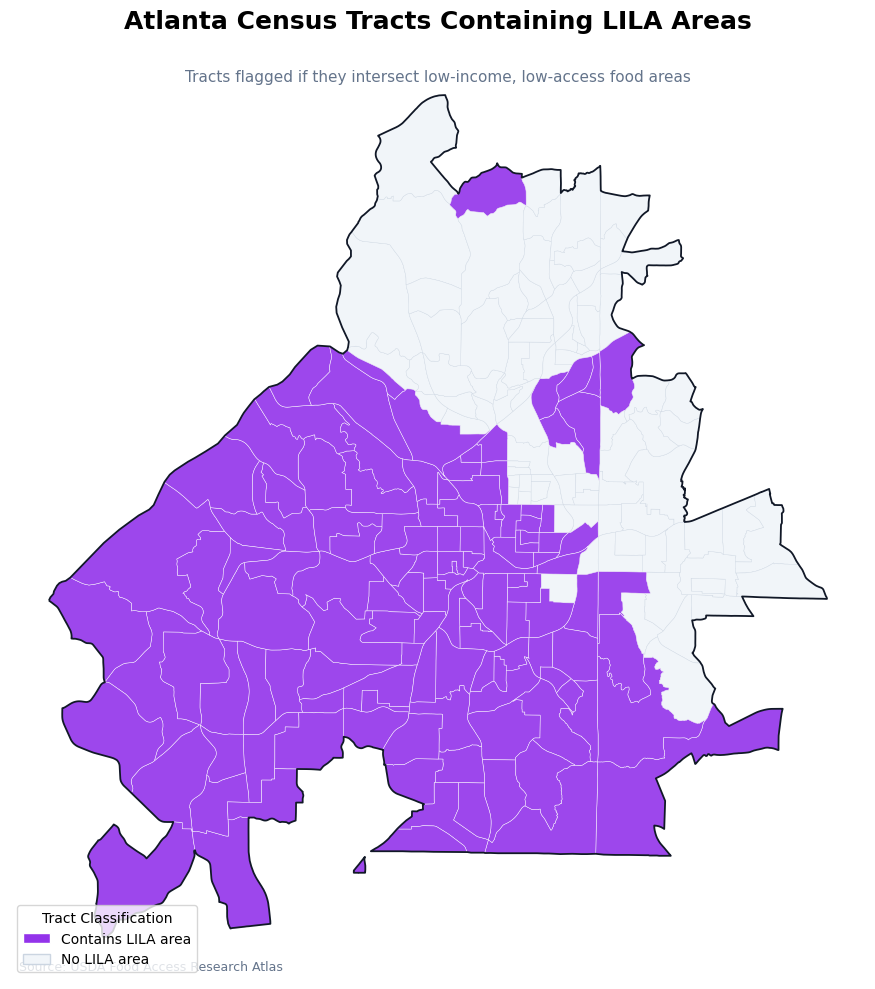

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(10, 10))


fig.patch.set_facecolor("white")
ax.set_facecolor("white")

atl[atl["contains_lila"] == 0].plot(
    ax=ax,
    color="#f1f5f9",
    edgecolor="#cbd5e1",
    linewidth=0.25
)


atl[atl["contains_lila"] == 1].plot(
    ax=ax,
    color="#9333ea",
    edgecolor="white",
    linewidth=0.35,
    alpha=0.9
)


atl.dissolve().boundary.plot(
    ax=ax,
    color="#111827",
    linewidth=1.3
)


ax.set_title(
    "Atlanta Census Tracts Containing LILA Areas",
    fontsize=18,
    fontweight="bold",
    pad=18
)


ax.text(
    0.5, 0.97,
    "Tracts flagged if they intersect low-income, low-access food areas",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="#64748b"
)


legend_elements = [
    Patch(facecolor="#9333ea", edgecolor="white", label="Contains LILA area"),
    Patch(facecolor="#f1f5f9", edgecolor="#cbd5e1", label="No LILA area")
]

ax.legend(
    handles=legend_elements,
    loc="lower left",
    frameon=True,
    fontsize=10,
    title="Tract Classification",
    title_fontsize=10
)

ax.text(
    0.01, 0.01,
    "Source: USDA Food Access Research Atlas",
    transform=ax.transAxes,
    fontsize=9,
    color="#64748b"
)

ax.set_axis_off()
plt.tight_layout()
plt.show()


Exploring LILA

In [19]:
lila[["LILAT_1A1", "LILAT_A", "LILAT_1A2", "LILAT_V"]].describe()

,LILAT_1A1,LILAT_A,LILAT_1A2,LILAT_V
count,6239.000000,6239.0,6239.000000,6239.000000
mean,0.593845,1.0,0.593845,0.828338
std,0.491153,0.0,0.491153,0.377117
min,0.000000,1.0,0.000000,0.000000
25%,0.000000,1.0,0.000000,1.000000
50%,1.000000,1.0,1.000000,1.000000
75%,1.000000,1.0,1.000000,1.000000
max,1.000000,1.0,1.000000,1.000000


MARTA(Can it be accessed easily?)
- Ridership
- Foot traffic intensity
-  High ridership = visibility and demand flow
-  Low ridership = isolated area

Business License Data (What already exists in the area?)
- Bus Name, Type/Category and Location
-  Grocery, Convenience Store, Restaurant
- Competition & Saturation


Tax Parcels (Can a buisness be built there?)
- Land use, ownership
- Whether a business is feasible

ATL Bounds
- City boundary 


In [20]:
import os
print(os.getcwd())

/Users/savannahimani/FreshFoodAccess_Project/FreshFoodAcessDashboard-InvestATL/notebooks


In [21]:
atl.columns
atl = atl.rename(columns={
    "P0010001": "population",
    "County_Nam": "county",
    "State_Name": "state"
})
atl.head()


,FID,GEOID,NAME,county,state,population,Longitude,Latitude,Shape__Are,Shape__Len,NPU,Shape__Area,Shape__Length,geometry
0,1,13121010307,Census Tract 103.07,Fulton County,Georgia,5425,-9.411489e+06,3.980673e+06,1.534330e+07,19185.041477,,1.534330e+07,19185.041477,"POLYGON ((-84.5659 33.64711, -84.56586 33.6472..."
1,2,13121011306,Census Tract 113.06,Fulton County,Georgia,3371,-9.406914e+06,3.980658e+06,1.038947e+07,16111.869887,,1.038947e+07,16111.869887,"POLYGON ((-84.52162 33.65584, -84.52143 33.655..."
2,3,13121006000,Census Tract 60,Fulton County,Georgia,3140,-9.399711e+06,3.993669e+06,2.270683e+06,7679.561985,,2.270683e+06,7679.561985,"POLYGON ((-84.44736 33.73455, -84.4472 33.7354..."
3,4,13121006100,Census Tract 61,Fulton County,Georgia,3269,-9.399488e+06,3.992305e+06,3.256851e+06,8565.052953,,3.256851e+06,8565.052953,"POLYGON ((-84.45043 33.72352, -84.4502 33.7242..."
4,5,13121007602,Census Tract 76.02,Fulton County,Georgia,2309,-9.402284e+06,3.990050e+06,4.882680e+06,12249.788746,,4.882680e+06,12249.788746,"POLYGON ((-84.47687 33.70507, -84.47685 33.706..."


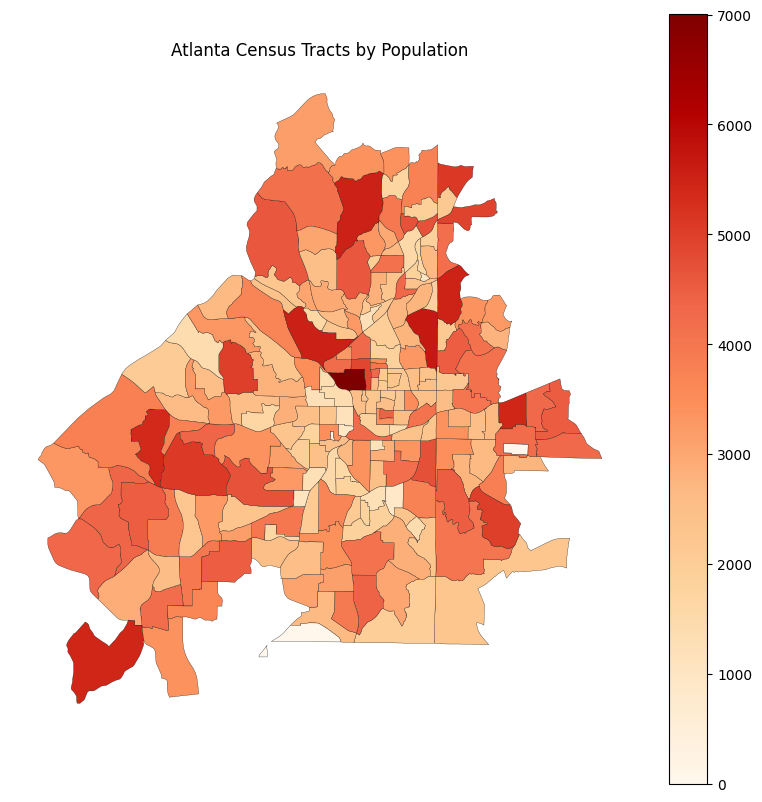

In [36]:
fig, ax = plt.subplots(figsize=(10, 10))
atl.plot(
    ax=ax,
    column="population",   # total population
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.2
)

ax.set_title("Atlanta Census Tracts by Population")
ax.set_axis_off()

plt.show()

In [23]:
snap.describe()
snap.columns
snap['Store Type'].value_counts()


Store Type
Convenience Store            1871
Combination Grocery/Other     254
Small Grocery Store           211
Medium Grocery Store          135
Supermarket                    83
Super Store                    71
Farmers' Market                44
Seafood Specialty              39
Meat/Poultry Specialty         29
Fruits/Veg Specialty           24
Large Grocery Store            19
Delivery Route                 18
Bakery Specialty               11
Food Buying Co-op               6
Military Commissary             1
Name: count, dtype: int64

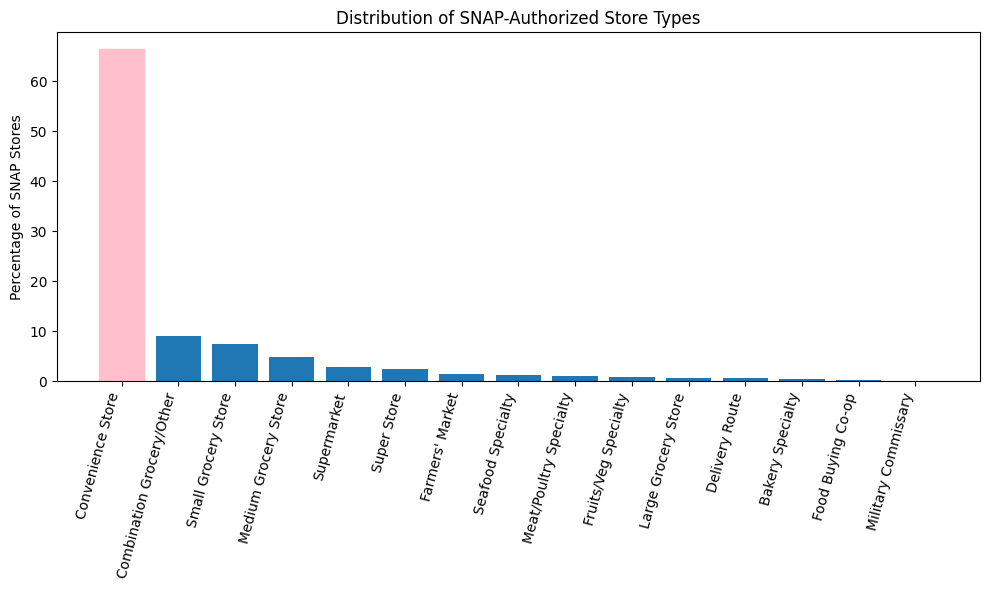

In [24]:
import matplotlib.pyplot as plt

# Get counts
counts = snap['Store Type'].value_counts()

# Convert to percentages
percent = counts / counts.sum() * 100

# Sort for readability
percent = percent.sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,6))
bars = plt.bar(percent.index, percent.values)

# Highlight convenience stores
for i, label in enumerate(percent.index):
    if label == 'Convenience Store':
        bars[i].set_color('pink')

plt.xticks(rotation=75, ha='right')
plt.ylabel('Percentage of SNAP Stores')
plt.title('Distribution of SNAP-Authorized Store Types')

plt.tight_layout()
plt.show()